<a href="https://colab.research.google.com/github/bettycdaba/Superstore-Sales-Analysis/blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Analysis Project

## Objective

The primary objective of this project is to analyze the Superstore dataset using Pandas to uncover key business insights. This includes identifying the most profitable product categories, evaluating regional performance, understanding customer segments, detecting seasonal sales patterns, and examining the relationship between sales and profit. The goal is to provide data-driven recommendations that can help the business optimize its strategy and improve overall profitability.

## About the dataset

Dataset Source: Kaggle (vivek468/superstore-dataset-final)

Dataset Shape: 9,986 rows and 21 columns

Time Period: 2014 to 2017

## 1. Load and explore data

### Load the dataset

In [27]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Superstore dataset
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Displaying the first few rows

In [11]:
# display the first few rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Checking datatypes

In [13]:
# check the datatypes in the dataset
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


### Checking dataset structure

#### Dataset Information

In [21]:
# Check the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#### Dataset Dimension

In [19]:
# Rows and columns of the dataset
print(f"Dataset Shape:{df.shape}")

Dataset Shape:(9994, 21)


#### Dataset Random Sample

In [23]:
#Dataset Sample
df.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9817,9818,CA-2015-162201,6/8/2015,6/12/2015,Standard Class,AG-10495,Andrew Gjertsen,Corporate,United States,Saint Petersburg,...,33710,South,FUR-FU-10001185,Furniture,Furnishings,Advantus Employee of the Month Certificate Fra...,173.208,7,0.2,45.4671


### Summary statistics

In [25]:
#Summary statistics of the dataset
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Data cleaning

### Identifying missing values

In [44]:
#Checking if any missing values exist
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("No missing values exist.")
else:
    print(f" Found {missing_count} missing values. Need to handle them.")

No missing values exist.


#### Visualization for missing values

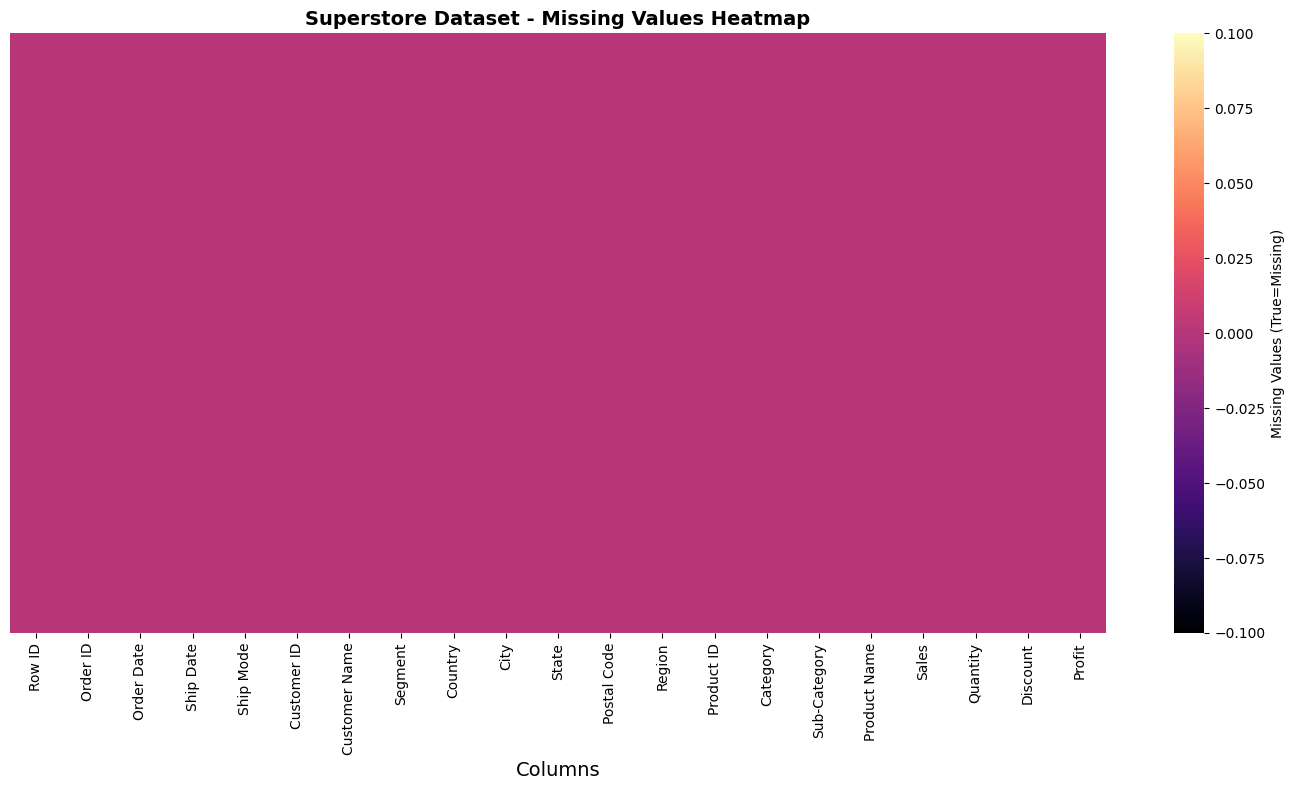

In [45]:
# Create heatmap to visualize missing values
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(),
            cbar=True,
            cmap='magma',
            yticklabels=False,
            cbar_kws={'label': 'Missing Values (True=Missing)'})
plt.title('Superstore Dataset - Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=14)
plt.tight_layout()
plt.show()

The magma colormap heatmap visually validates that the dataset has zero missing values, as no light-colored cells (representing True/missing) appear anywhere in the visualization.

### Data type correction

In [46]:
#Parse string dates to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print('✓ Date columns converted to datetime format.')

✓ Date columns converted to datetime format.


### String Conversion

In [47]:
#Convert to string
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)

print('✓ Postal Code converted to string.')

✓ Postal Code converted to string.


### Removing duplicates

In [48]:
# Remove duplicate order-product pairs
df.drop_duplicates(subset=['Order ID', 'Product ID'], keep='first', inplace=True)
print("✓ Duplicates removed")

✓ Duplicates removed


## 3. Feature Engineering

### Extracting month and year

In [50]:
# Extract Year-Month as a single period
df['Year_Month'] = df['Order Date'].dt.to_period('M')

#Result
print(df[['Order Date', 'Year_Month']].head())

  Order Date Year_Month
0 2016-11-08    2016-11
1 2016-11-08    2016-11
2 2016-06-12    2016-06
3 2015-10-11    2015-10
4 2015-10-11    2015-10


### Creating and verifying a new column

In [55]:
# Create Sales_Tier column
df['Sales_Tier'] = pd.cut(df['Sales'],
                          bins=[0, 100, 500, 1000, float('inf')],
                          labels=['Low', 'Medium', 'High', 'Very High'])

# View both Sales and Sales_Tier columns
print("SALES AND SALES_TIER COLUMNS")
print(df[['Sales', 'Sales_Tier']].head(10))

SALES AND SALES_TIER COLUMNS
      Sales Sales_Tier
0  261.9600     Medium
1  731.9400       High
2   14.6200        Low
3  957.5775       High
4   22.3680        Low
5   48.8600        Low
6    7.2800        Low
7  907.1520       High
8   18.5040        Low
9  114.9000     Medium


In [56]:
#VERIFICATION
print("VERIFYING Sales_Tier COLUMN")

#Value counts
print("\n1️ VALUE COUNTS:")
print(df['Sales_Tier'].value_counts())

#Logic check for Low tier
print("\n2️ LOGIC CHECK - Low tier should have Sales <= 100:")
low_tier = df[df['Sales_Tier'] == 'Low']
print(f"   Max sales in Low tier: ${low_tier['Sales'].max():.2f}")
print(f"   All <= 100: {(low_tier['Sales'] <= 100).all()}")

#Logic check for Very High tier
print("\n3️ LOGIC CHECK - Very High tier should have Sales > 1000:")
high_tier = df[df['Sales_Tier'] == 'Very High']
print(f"   Min sales in Very High tier: ${high_tier['Sales'].min():.2f}")
print(f"   All > 1000: {(high_tier['Sales'] > 1000).all()}")

VERIFYING Sales_Tier COLUMN

1️ VALUE COUNTS:
Sales_Tier
Low          6226
Medium       2599
High          693
Very High     468
Name: count, dtype: int64

2️ LOGIC CHECK - Low tier should have Sales <= 100:
   Max sales in Low tier: $100.00
   All <= 100: True

3️ LOGIC CHECK - Very High tier should have Sales > 1000:
   Min sales in Very High tier: $1000.02
   All > 1000: True


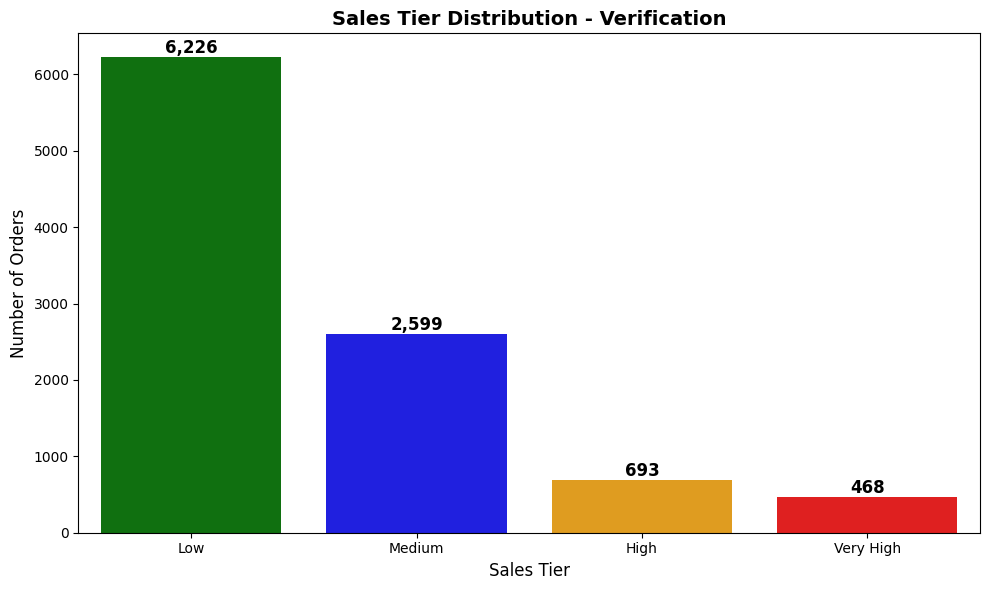

In [58]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Create bar chart with exact numbers on top
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Sales_Tier', order=['Low', 'Medium', 'High', 'Very High'],
                    palette=['green', 'blue', 'orange', 'red'])

# Add count labels on top of each bar
for i, tier in enumerate(['Low', 'Medium', 'High', 'Very High']):
    count = len(df[df['Sales_Tier'] == tier])
    ax.text(i, count + 50, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.title('Sales Tier Distribution - Verification', fontsize=14, fontweight='bold')
plt.xlabel('Sales Tier', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Group by and aggregation

### Total sales by category

In [60]:
# Calculate total sales by category
total_sales_by_category = df.groupby('Category')['Sales'].sum()
total_sales = df['Sales'].sum()
percentages = (total_sales_by_category / total_sales) * 100

# Display the result
print("TOTAL SALES BY CATEGORY")
print(total_sales_by_category)
print("\nPERCENTAGES")
print(percentages.round(1))

TOTAL SALES BY CATEGORY
Category
Furniture          741432.0433
Office Supplies    718317.7920
Technology         835759.7370
Name: Sales, dtype: float64

PERCENTAGES
Category
Furniture          32.3
Office Supplies    31.3
Technology         36.4
Name: Sales, dtype: float64


Sales are evenly distributed across all three product categories. Technology emerges as the leading category with 835,760 dollars in sales, representing 36.4% of total revenue. Furniture follows closely at 741,432 dollars (32.3%), while Office Supplies contributes 718,318 dollars (31.3%). The narrow 5.1% gap between the top and bottom categories indicates balanced performance across all product segments, suggesting the store does not overly rely on any single category for revenue generation.

### Total profit by region

In [61]:
# Calculate total profit by region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Display the result
print("TOTAL PROFIT BY REGION")
print(profit_by_region)

TOTAL PROFIT BY REGION
Region
West       108404.3777
East        91353.8822
South       46549.1972
Central     39706.3625
Name: Profit, dtype: float64


Profit analysis by region reveals significant performance gaps. The East region leads with the highest profit, followed by the West, while the central region trails substantially behind. This disparity suggests regional factors such as pricing, customer behavior, or operational costs vary considerably. The East and West regions serve as profit anchors, while the Central and South regions represent growth opportunities. Immediate attention to the Central region's underperformance could yield significant overall profit improvement.

### Top 5 customers based on sales

In [63]:
# Identify top 5 customers based on sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

# Display
print("TOP 5 CUSTOMERS BY SALES")
print(top_customers)

TOP 5 CUSTOMERS BY SALES
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


### Sales trends over time

In [64]:
# Year_Month
monthly_sales = df.groupby('Year_Month')['Sales'].sum()

# Display
print("MONTHLY SALES TRENDS")
print(monthly_sales)

MONTHLY SALES TRENDS
Year_Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28013.9730
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28675.2650
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51670.1950
2016-04     38458.0790
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73360.9049
2016-10     59687.7450
2016-11     79411.9658
2016-12     96712.6630
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
20

Monthly sales reveal a strong seasonal pattern with holiday peaks in November-December and post-holiday lows in January-February.

## 5. Pivot table

### Sales by category and region

In [65]:
# Create pivot table for Sales by Category and Region
sales_category_region = pd.pivot_table(df,
                                       values='Sales',
                                       index='Category',
                                       columns='Region',
                                       aggfunc='sum')

# Display
print("SALES BY CATEGORY AND REGION")
print(sales_category_region)

SALES BY CATEGORY AND REGION
Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208009.832  117012.304  252612.7435
Office Supplies  167026.4150  204922.555  125515.573  220853.2490
Technology       170416.3120  264973.981  148479.948  251889.4960


### Sales trends by segment over time

In [66]:
# Calculate sales by Segment
segment_trends = df.groupby(['Year_Month', 'Segment'])['Sales'].sum().unstack()

# Display
print("SALES TRENDS BY SEGMENT OVER TIME")
print(segment_trends)

SALES TRENDS BY SEGMENT OVER TIME
Segment       Consumer   Corporate  Home Office
Year_Month                                     
2014-01      6927.8170   1701.5280    5607.5500
2014-02      3167.8540   1183.6680     168.3700
2014-03     11869.3040  11106.7990   32714.9060
2014-04      9108.6120  14131.7290    4773.6320
2014-05     12819.1630   9142.0000    1687.1240
2014-06     25923.7476   3970.9140    4700.4660
2014-07     20197.7400  10032.9880    3715.6650
2014-08     16215.2635   7451.7740    4242.4310
2014-09     59690.6500  15507.7450    6578.9558
2014-10     16246.6970  12637.6780    2569.0180
2014-11     46571.9780  20994.4947   11062.2440
2014-12     37357.9865  20573.5560   11614.0780
2015-01     14274.9836   3382.4640     516.6280
2015-02      9269.0180   2565.2570     117.1360
2015-03     17418.8900  16332.0184    4975.3436
2015-04     22626.4055   4121.0440    7447.7590
2015-05     20879.1790   5454.9395    3797.5680
2015-06     12824.5040   9404.0890    2568.6990
2015-0

The Consumer segment generates the highest sales across all time periods, consistently outperforming both Corporate and Home Office segments. This indicates that individual customers are the store's primary revenue source.

### Profit by sub-category

In [69]:
# Pivot table with Category and Sub-Category
profit_subcategory = pd.pivot_table(df,
                                     values='Profit',
                                     index='Sub-Category',
                                     columns='Category',
                                     aggfunc='sum',
                                     fill_value=0)

# Display
print("PROFIT BY SUB-CATEGORY AND CATEGORY")
print(profit_subcategory.round(2))

# Add total column
profit_subcategory['Total'] = profit_subcategory.sum(axis=1)
profit_subcategory_sorted = profit_subcategory.sort_values('Total', ascending=False)

print("SORTED BY TOTAL PROFIT (Highest to Lowest)")
print(profit_subcategory_sorted.round(2))

PROFIT BY SUB-CATEGORY AND CATEGORY
Category      Furniture  Office Supplies  Technology
Sub-Category                                        
Accessories        0.00             0.00    41867.82
Appliances         0.00         18138.01        0.00
Art                0.00          6527.79        0.00
Binders            0.00         30180.34        0.00
Bookcases      -3472.56             0.00        0.00
Chairs         26602.23             0.00        0.00
Copiers            0.00             0.00    55617.82
Envelopes          0.00          6964.18        0.00
Fasteners          0.00           949.52        0.00
Furnishings    12976.09             0.00        0.00
Labels             0.00          5546.25        0.00
Machines           0.00             0.00     3384.76
Paper              0.00         34009.47        0.00
Phones             0.00             0.00    44515.73
Storage            0.00         21120.96        0.00
Supplies           0.00         -1189.10        0.00
Tables    

Profit analysis by sub-category reveals that Technology products (Copiers, Phones, Machines) are the primary profit drivers, contributing over $100,000 combined. Office Supplies sub-categories provide steady moderate profits, with Accessories and Binders leading. Furniture presents a mixed picture - Chairs and Bookcases are profitable, but Tables operate at a loss. Addressing the Tables sub-category through price adjustments, cost reduction, or potential discontinuation could significantly improve overall Furniture profitability

## 5. Data splitting and merging

### Splitting the dataset

In [81]:
# DataFrame 1: Order & Customer columns
df_order_customer = df[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
                         'Customer ID', 'Customer Name', 'Segment',
                         'Country', 'City', 'State', 'Postal Code', 'Region']].copy()

# DataFrame 2: Product & Sales columns
df_product_sales = df[['Product ID', 'Category', 'Sub-Category', 'Product Name',
                        'Sales', 'Quantity', 'Discount', 'Profit',
                        'Row ID', 'Year_Month', 'Sales_Tier']].copy()

print("Order/Customer vs Product/Sales")
print(f"Order & Customer DF: {df_order_customer.shape} (12 columns)")
print(f"Product & Sales DF: {df_product_sales.shape} (11 columns)")


Order/Customer vs Product/Sales
Order & Customer DF: (9986, 12) (12 columns)
Product & Sales DF: (9986, 11) (11 columns)


### Merging back the dataset

In [82]:
# Merge back the split datasets
df_merged = pd.concat([df_order_customer, df_product_sales], axis=1)
print("Merged Successfully")

Merged Successfully


### Verification of the merged result

In [83]:
# Verification that merge is correct
print("Merge verification:")
print(f"Original shape: {df.shape}")
print(f"Merged shape: {df_merged.shape}")
print(f"Correct: {df.shape == df_merged.shape}")

Merge verification:
Original shape: (9986, 23)
Merged shape: (9986, 23)
Correct: True


## Data Visualization

### Sales trend over time

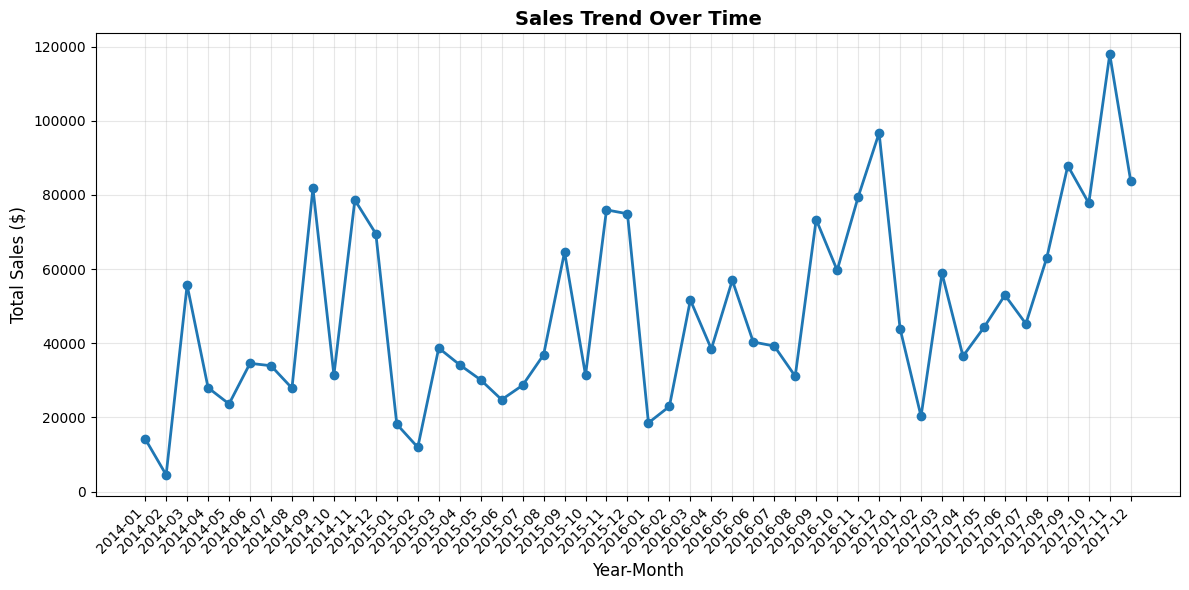

In [84]:
# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)

# Customize
plt.title('Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sales show a clear annual cycle: strong growth in November–December, a sharp drop in January–February, and a steady upward trend over the four‑year period.

### Sales by category

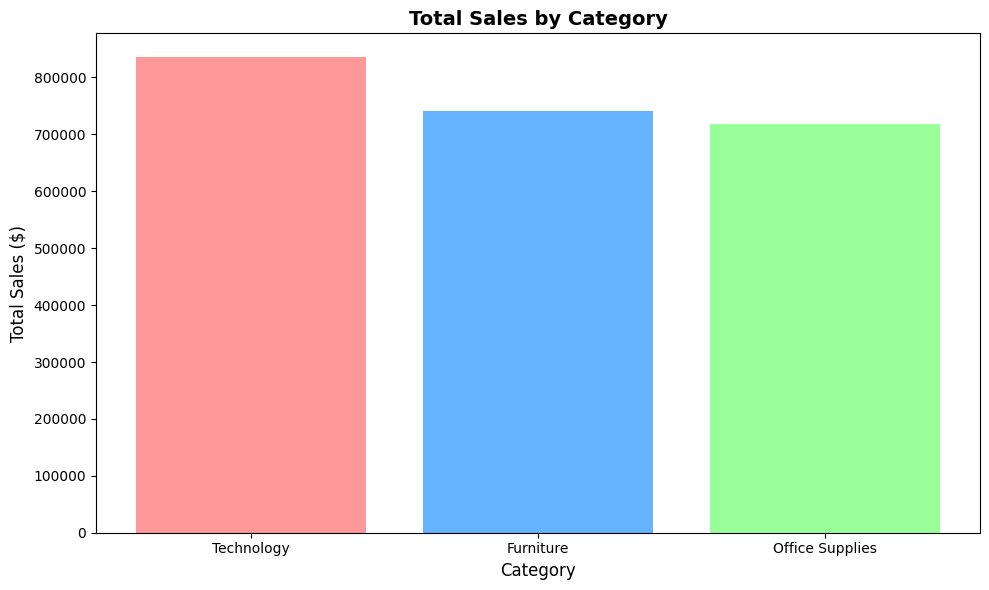

In [86]:
# Calculate total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']
bars = plt.bar(category_sales.index, category_sales.values, color=colors)

# Customize
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

Technology leads in sales, followed closely by Furniture and Office Supplies, with all three categories showing a balanced revenue distribution.

### Profit by region

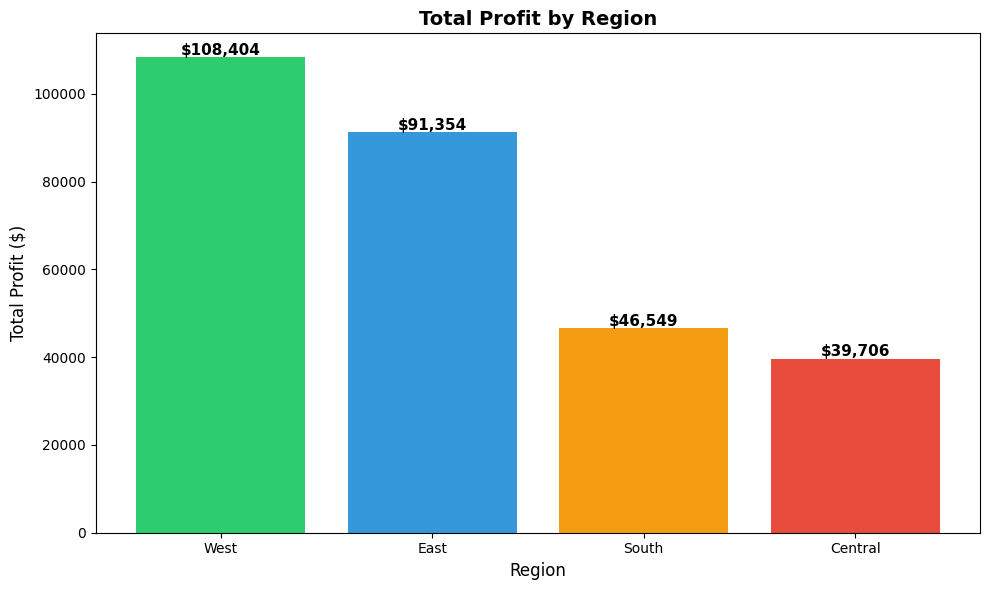

In [88]:
# Calculate total profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = plt.bar(region_profit.index, region_profit.values, color=colors)

# Add value labels on top of bars
for bar, value in zip(bars, region_profit.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${value:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Customize
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.tight_layout()
plt.show()

The West and East regions generate the highest profits, together accounting for nearly 75% of the total (108K dollars and 91K dollars respectively). In contrast, Central is the lowest-performing region at just 40K dollars, followed closely by South at 47K dollars, signaling an urgent need for strategic review in both regions.

### Segment Distribution

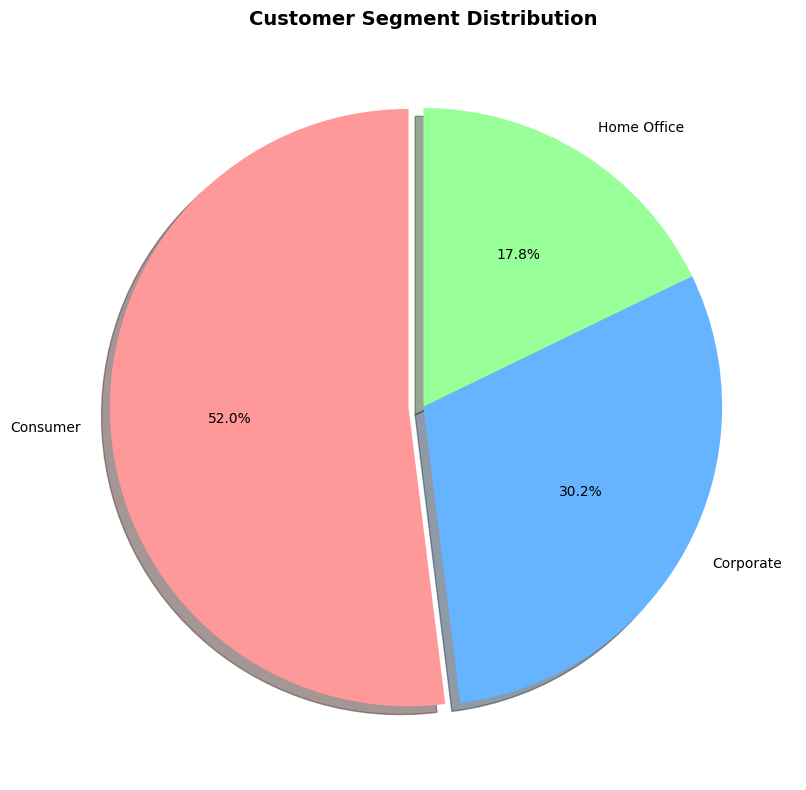

In [89]:
# Calculate segment distribution
segment_distribution = df['Segment'].value_counts()

# Create pie chart
plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0, 0)

plt.pie(segment_distribution.values,
        labels=segment_distribution.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        startangle=90,
        shadow=True)

plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Consumer segment dominates with 52% of customers, followed by Corporate (30%) and Home Office (18%). More than half of all customers are individual consumers, suggesting marketing strategies should prioritize this segment.

## 8. Business insights from category

### Profitable category

In [90]:
# Calculate profit by category
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(profit_by_category)

Category
Technology         145386.1344
Office Supplies    122247.4038
Furniture           18380.2814
Name: Profit, dtype: float64


echnology leads in profit at 145,000 dollars, while Furniture severely underperforms at just 18,000 dollars despite similar sales volume. This signals a clear profitability crisis in the Furniture category that needs urgent attention.

### Least perfoming region

West (108K dollars) and East (91K dollars) drive nearly 75% of total profit. Meanwhile, Central (40K dollars) and South (47K dollars) lag significantly behind , with Central as the weakest performer highlighting an urgent need for strategic intervention in both regions.

### Sales-Profit relationship

Sales and profit generally move together, but Furniture proves this is not always true.

Technology generates 835,760 dollars in sales and delivers 145,000 dollars in profit. This is how a successful category should perform.

Furniture tells a very different story. With 741,432 dollars in sales, it nearly matches Technology's revenue. Yet its profit is only 18,380 dollars. That is nearly eight times less profit for almost the same sales volume.

The problem runs deeper at the sub-category level. Tables lose 17,725 dollars. Bookcases lose 3,472 dollars. These products sell, but every sale destroys value. Customers buy them, and the company loses money on each transaction.

The likely causes are excessive discounts, high shipping costs, or poor pricing strategies.

### Important trends over time

Sales follow a clear and repeating seasonal pattern every year.

November and December consistently show the highest sales each year. In 2017, November reached 117,903 dollars, the single highest month in the entire dataset. December also performs strongly at 83,727 dollars.

January and February consistently show the lowest sales each year. January 2015 had only 18,174 dollars, and February 2015 dropped to 11,951 dollars. This sharp drop happens every year right after the holiday season.

Between March and October, sales remain moderate and stable, typically ranging between 30,000 and 80,000 dollars. September often shows a secondary peak before the final holiday surge.

Over the four year period from 2014 to 2017, sales show steady year over year growth. The peaks get higher each year. The lows also get higher each year. This indicates healthy business expansion despite the seasonal ups and downs.

## Conclusion

The Superstore has a healthy and balanced revenue stream across categories and regions, with Technology leading at 835,760 dollars and all three categories within a narrow 5% range. However, profitability tells a different story. Technology drives profit at 145,000 dollars, while Furniture generates only 18,380 dollars despite nearly identical sales volume. At the sub-category level, Tables lose 17,725 dollars and Bookcases lose 3,472 dollars, meaning every sale of these products destroys value. Regionally, West and East account for nearly 75% of total profit, while Central and South lag significantly behind at just 40,000 and 47,000 dollars respectively. Sales follow a strong seasonal pattern, peaking in November and December and crashing in January and February, but show steady year-over-year growth from 2014 to 2017. The Consumer segment dominates with 52% of customers. The key lesson is clear: revenue growth alone is not enough. The store must focus on profitable growth, not just more sales. Fixing Furniture, Tables, Bookcases, and the Central region would significantly improve overall profitability.